# Module 11 Practical: Swimmer Analysis and Graph Analytics

This notebook combines the two practical notebooks into one coherent workflow.

We will:

1. automatically download the swimmer dataset;
2. reshape daily data into monthly data;
3. inspect performance, variance and consistency;
4. fit simple linear regression models;
5. perform K-Means clustering;
6. create graphs from swimmer relationships;
7. calculate graph centrality and PageRank; and
8. explore two additional graph examples.

The swimmer dataset is simulated and is used only for teaching.

## 1. Import libraries

We use:

- `pandas` and `numpy` for data preparation;
- `matplotlib` and `seaborn` for visualisation;
- `scikit-learn` for regression and clustering; and
- `networkx` for graph analytics.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Matplotlib is building the font cache; this may take a moment.


## 2. Download the swimmer dataset

The notebook downloads the CSV automatically from Google Drive.

If the file already exists in the current folder, it will not download it again.

In [2]:
file_id = "1YTFUom5uKraevozIUcpfiBsGvEoCJP2o"
data_file = Path("daily_swimming_distance_2019_2020.csv")

if not data_file.exists():
    download_url = (
        "https://drive.google.com/uc?"
        f"export=download&id={file_id}"
    )
    urlretrieve(download_url, data_file)
    print("Dataset downloaded.")
else:
    print("Dataset already exists.")

print(data_file)

Dataset already exists.
daily_swimming_distance_2019_2020.csv


## 3. Load and inspect the data

Each row represents one swimmer.

The remaining columns represent daily swimming distances from 2019 to 2020.

In [3]:
df = pd.read_csv(data_file)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (15, 732)


,Swimmer,01/01/2019,01/02/2019,01/03/2019,01/04/2019,01/05/2019,01/06/2019,01/07/2019,01/08/2019,01/09/2019,01/10/2019,01/11/2019,01/12/2019,01/13/2019,01/14/2019,01/15/2019,01/16/2019,01/17/2019,01/18/2019,01/19/2019,01/20/2019,01/21/2019,01/22/2019,01/23/2019,01/24/2019,01/25/2019,01/26/2019,01/27/2019,01/28/2019,01/29/2019,01/30/2019,01/31/2019,02/01/2019,02/02/2019,02/03/2019,02/04/2019,02/05/2019,02/06/2019,02/07/2019,02/08/2019,...,11/22/2020,11/23/2020,11/24/2020,11/25/2020,11/26/2020,11/27/2020,11/28/2020,11/29/2020,11/30/2020,12/01/2020,12/02/2020,12/03/2020,12/04/2020,12/05/2020,12/06/2020,12/07/2020,12/08/2020,12/09/2020,12/10/2020,12/11/2020,12/12/2020,12/13/2020,12/14/2020,12/15/2020,12/16/2020,12/17/2020,12/18/2020,12/19/2020,12/20/2020,12/21/2020,12/22/2020,12/23/2020,12/24/2020,12/25/2020,12/26/2020,12/27/2020,12/28/2020,12/29/2020,12/30/2020,12/31/2020
0,Swimmer 1,3890.365552,4472.320001,4449.722978,511.173409,1026.403801,710.314155,1748.536498,3631.763990,1920.910162,848.595745,4616.502668,999.583088,1151.732472,1040.135054,3489.518266,946.100280,3447.088028,635.455489,2266.076457,1924.592775,2582.570298,526.089783,968.715738,524.124155,3667.064583,3837.503668,3385.458677,3431.477014,2121.906494,3030.072584,4048.630216,1911.420293,2576.827547,4028.611476,2804.195348,4725.861065,1402.979284,741.049719,4300.826123,...,3519.299248,3945.063149,4084.033423,1188.662992,4151.490124,2580.314644,684.346822,3917.412376,832.118596,660.094556,1727.024338,4845.154007,4373.844805,3495.286868,556.060643,2062.690727,925.137567,2737.242856,4444.011194,3473.823853,1240.051003,3023.594384,1734.548507,4049.336247,4643.005267,2088.268864,3308.486248,4237.284839,4697.255127,885.524321,4039.414093,518.679850,508.913097,3379.990807,2492.178123,3247.467220,2907.244185,4874.498632,2928.768332,2335.284379
1,Swimmer 2,4065.478323,1060.922728,640.968389,2018.902161,3473.583286,3545.475506,1895.694941,868.093270,2283.254492,673.505103,2379.151167,4557.763804,1142.054950,3735.897287,3131.679521,1296.845378,3127.078070,801.240950,2871.063860,1301.076331,657.402142,924.580432,3121.498947,1658.029896,670.171192,1945.819688,3142.819474,928.208922,3440.854212,987.523424,4896.097448,1022.235902,2999.553956,521.170402,4085.648455,3407.152169,4910.851768,2639.546651,669.561907,...,737.009913,673.646309,608.466562,2792.557795,671.189848,1282.887266,4234.193298,562.227579,725.774803,4620.720003,2709.281152,2198.476329,4904.280776,3568.038003,512.461574,527.694515,4506.186253,2637.601142,651.793635,4525.795722,711.047454,1190.752226,4208.542537,818.133796,873.035811,2957.208658,4110.057518,4840.589256,3803.203370,2267.986509,1894.767965,615.241427,1898.787019,707.997489,543.572209,2692.566468,2799.330260,1718.673233,971.741153,4659.405370
2,Swimmer 3,686.977400,3214.927641,587.997758,1619.654730,3278.417961,2042.162311,1131.075981,2533.427152,3512.131635,1801.297370,4563.664289,2861.478302,4711.090220,849.903111,1743.691179,2711.020886,1630.015790,2995.887640,875.395099,4376.668437,720.718714,2664.059110,4463.803418,980.485162,956.691331,943.384611,899.797139,838.923258,4510.640396,1760.199960,890.251623,3020.743398,1422.108064,627.551332,4157.155915,749.274659,3186.899409,728.208528,836.762942,...,3245.080515,4357.798648,1647.409751,801.034174,3540.357898,959.528381,2870.901196,1014.899346,2330.163043,601.999381,4969.210944,1281.596162,4732.641528,596.651652,4832.569335,976.449124,847.560056,520.912842,2272.946487,1637.996325,947.426714,4788.993455,758.119729,2849.611607,918.153506,683.282311,1141.137282,692.921769,702.952547,2000.971045,4608.676529,4961.465559,2164.140457,1331.049435,884.028728,550.183314,4905.696059,618.828426,729.152585,2427.204805
3,Swimmer 4,3804.435523,1408.807760,789.315249,504.156443,1648.088359,715.063501,797.084022,909.091609,574.056998,4463.966330,4897.670316,793.391445,529.024760,1920.620609,4306.316318,824.244911,747.894625,1937.595543,2598.300387,703.710180,4611.206311,4013.783574,560.890906,610.891989,2422.405094,4426

## 4. Convert the daily data into monthly data

The original dataset is in **wide format**:

```text
Swimmer | 01/01/2019 | 01/02/2019 | ...
```

For analysis, it is easier to convert it into **long format**:

```text
Swimmer | Date | Distance
```

We then create a month number from 1 to 24 and calculate the total swimming distance for each month.

In [4]:
df_long = df.melt(
    id_vars="Swimmer",
    var_name="Date",
    value_name="Distance"
)

df_long["Date"] = pd.to_datetime(
    df_long["Date"],
    format="%m/%d/%Y"
)

df_long["Month"] = (
    (df_long["Date"].dt.year - 2019) * 12
    + df_long["Date"].dt.month
).astype(int)

df_monthly = (
    df_long
    .groupby(["Swimmer", "Month"], as_index=False)["Distance"]
    .sum()
)

df_monthly.head()

,Swimmer,Month,Distance
0,Swimmer 1,1,71850.504074
1,Swimmer 1,2,62912.205640
2,Swimmer 1,3,69639.506391
3,Swimmer 1,4,51118.255907
4,Swimmer 1,5,73367.804805


## 5. Compare swimmer performance

We calculate:

- **average monthly distance** — higher values indicate greater average distance;
- **standard deviation** — lower values indicate more consistent performance; and
- **variance** — larger values indicate greater fluctuation over time.

In [5]:
average_monthly = (
    df_monthly
    .groupby("Swimmer")["Distance"]
    .mean()
    .sort_values(ascending=False)
)

consistency = (
    df_monthly
    .groupby("Swimmer")["Distance"]
    .std()
    .sort_values()
)

variance = (
    df_monthly
    .groupby("Swimmer")["Distance"]
    .var()
    .sort_values(ascending=False)
)

print("Top 3 by average monthly distance:")
print(average_monthly.head(3))

print("\nTop 3 most consistent:")
print(consistency.head(3))

print("\nTop 3 highest variance:")
print(variance.head(3))

Top 3 by average monthly distance:
Swimmer
Swimmer 1    71143.109402
Swimmer 8    70803.247814
Swimmer 5    70421.657882
Name: Distance, dtype: float64

Top 3 most consistent:
Swimmer
Swimmer 15    6177.582657
Swimmer 12    6696.277199
Swimmer 8     6840.716092
Name: Distance, dtype: float64

Top 3 highest variance:
Swimmer
Swimmer 6     8.910104e+07
Swimmer 1     8.898444e+07
Swimmer 10    7.795531e+07
Name: Distance, dtype: float64


## 6. Fit linear regression models for the top three swimmers

We use the three swimmers with the highest average monthly distance.

For each swimmer:

- `Month` is the independent variable;
- `Distance` is the dependent variable; and
- the regression line represents the overall trend over time.

In [6]:
top_swimmers = average_monthly.head(3).index.tolist()

models = {}
regression_results = []

for swimmer in top_swimmers:
    swimmer_data = df_monthly[
        df_monthly["Swimmer"] == swimmer
    ]

    X = swimmer_data[["Month"]]
    y = swimmer_data["Distance"]

    model = LinearRegression()
    model.fit(X, y)

    models[swimmer] = model

    regression_results.append({
        "Swimmer": swimmer,
        "Slope": model.coef_[0],
        "Intercept": model.intercept_,
        "R_squared": model.score(X, y),
        "Variance": y.var()
    })

regression_results = pd.DataFrame(
    regression_results
).sort_values("Variance", ascending=False)

regression_results

,Swimmer,Slope,Intercept,R_squared,Variance
0,Swimmer 1,-14.221897,71320.883115,0.000114,8.898444e+07
2,Swimmer 5,66.808040,69586.557382,0.003186,7.003965e+07
1,Swimmer 8,-322.376559,74832.954808,0.111044,4.679540e+07


The swimmer with the highest variance among the top three will be used in the clustering section.

In [7]:
selected_swimmer = regression_results.iloc[0]["Swimmer"]

print(
    "Selected swimmer for clustering:",
    selected_swimmer
)

Selected swimmer for clustering: Swimmer 1


## 7. Predict the next six months

This is a simple extrapolation using the fitted linear regression model.

The predictions are for demonstration only. Extrapolation becomes less reliable the further we move beyond the observed data.

In [8]:
future_months = pd.DataFrame({
    "Month": range(
        df_monthly["Month"].max() + 1,
        df_monthly["Month"].max() + 7
    )
})

prediction_rows = []

for swimmer, model in models.items():
    predicted_distance = model.predict(future_months)

    for month, prediction in zip(
        future_months["Month"],
        predicted_distance
    ):
        prediction_rows.append({
            "Swimmer": swimmer,
            "Month": month,
            "Predicted_Distance": prediction
        })

predictions = pd.DataFrame(prediction_rows)

predictions.head(10)

,Swimmer,Month,Predicted_Distance
0,Swimmer 1,25,70965.335689
1,Swimmer 1,26,70951.113792
2,Swimmer 1,27,70936.891895
3,Swimmer 1,28,70922.669998
4,Swimmer 1,29,70908.448101
5,Swimmer 1,30,70894.226204
6,Swimmer 8,25,66773.540821
7,Swimmer 8,26,66451.164261
8,Swimmer 8,27,66128.787702
9,Swimmer 8,28,65806.411142


## 8. K-Means clustering for the selected swimmer

K-Means groups months with similar swimming distances.

First, we use the **elbow method** to inspect several possible values of K.

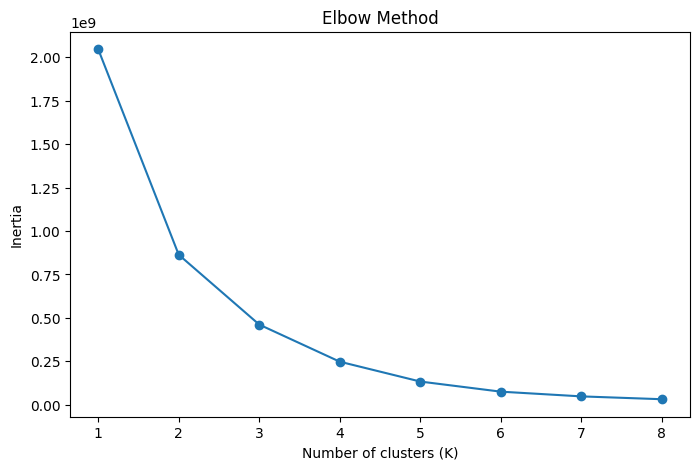

In [9]:
selected_data = (
    df_monthly[
        df_monthly["Swimmer"] == selected_swimmer
    ][["Month", "Distance"]]
    .copy()
)

X_cluster = selected_data[["Distance"]]

inertia = []

for k in range(1, 9):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X_cluster)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, 9),
    inertia,
    marker="o"
)
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

For this practical, we use **K = 5** to create five performance groups.

Students can change `number_of_clusters` after inspecting the elbow plot.

In [10]:
number_of_clusters = 5

kmeans = KMeans(
    n_clusters=number_of_clusters,
    random_state=42,
    n_init=10
)

selected_data["Cluster"] = kmeans.fit_predict(
    X_cluster
)

selected_data

,Month,Distance,Cluster
0,1,71850.504074,3
1,2,62912.205640,2
2,3,69639.506391,3
3,4,51118.255907,4
4,5,73367.804805,3
5,6,97758.418068,0
6,7,76020.798506,1
7,8,80844.618926,1
8,9,76083.522391,1
9,10,77978.033315,1


## 9. Visualise the clusters over time

Each point represents one month.

Months with similar swimming distances receive the same cluster label.

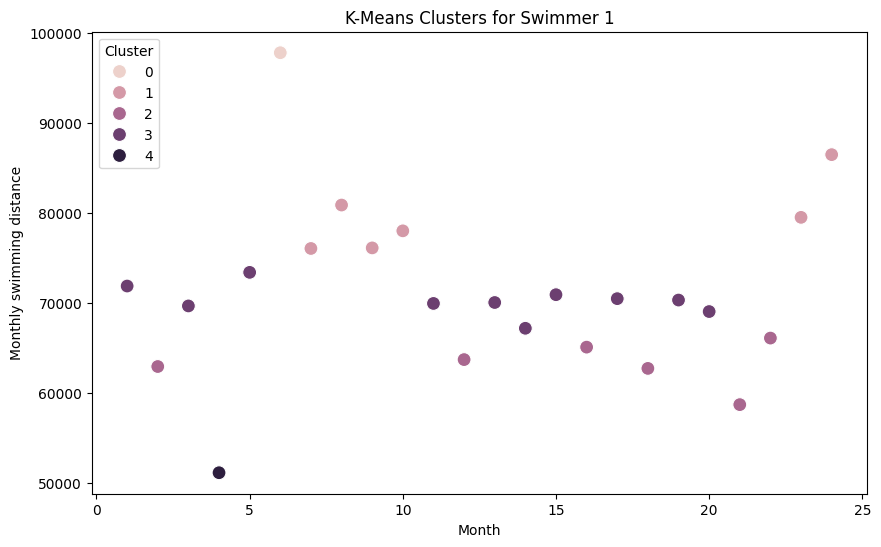

In [11]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=selected_data,
    x="Month",
    y="Distance",
    hue="Cluster",
    s=100
)

plt.title(
    f"K-Means Clusters for {selected_swimmer}"
)
plt.xlabel("Month")
plt.ylabel("Monthly swimming distance")
plt.show()

## 10. Validate the clustering

The **silhouette score** measures how well observations fit their assigned clusters.

The score ranges approximately from `-1` to `1`.

- values closer to `1` indicate better-separated clusters;
- values near `0` indicate overlapping clusters.

In [12]:
silhouette = silhouette_score(
    X_cluster,
    selected_data["Cluster"]
)

print(
    "Silhouette score:",
    round(silhouette, 3)
)

Silhouette score: 0.525


## 11. Simple outlier detection using IQR

The interquartile range is:

```text
IQR = Q3 - Q1
```

A common rule labels values below `Q1 - 1.5 × IQR` or above `Q3 + 1.5 × IQR` as possible outliers.

In [13]:
Q1 = selected_data["Distance"].quantile(0.25)
Q3 = selected_data["Distance"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = selected_data[
    (selected_data["Distance"] < lower_bound)
    | (selected_data["Distance"] > upper_bound)
]

print("Lower bound:", round(lower_bound, 2))
print("Upper bound:", round(upper_bound, 2))

outliers

Lower bound: 50494.11
Upper bound: 91361.9


,Month,Distance,Cluster
5,6,97758.418068,0


# Part 2: Graph Analytics

A graph contains:

- **nodes** — the objects we are studying; and
- **edges** — relationships between those objects.

Here, each swimmer is a node.

We will define an edge using the similarity of the swimmers' monthly distance patterns.

## 12. Create a monthly swimmer matrix

Rows are months and columns are swimmers.

This makes it easy to compare each pair of swimmers across the same 24 months.

In [14]:
monthly_matrix = df_monthly.pivot(
    index="Month",
    columns="Swimmer",
    values="Distance"
)

monthly_matrix.head()

Swimmer,Swimmer 1,Swimmer 10,Swimmer 11,Swimmer 12,Swimmer 13,Swimmer 14,Swimmer 15,Swimmer 2,Swimmer 3,Swimmer 4,Swimmer 5,Swimmer 6,Swimmer 7,Swimmer 8,Swimmer 9
Month,,,,,,,,,,,,,,,
1,71850.504074,68521.851468,58324.651416,69156.190464,72548.794501,80208.591332,77406.748723,67242.735294,67355.839616,64322.572436,69983.309582,71262.599898,65351.106494,73905.622686,76382.581603
2,62912.205640,56637.146446,64413.263430,63991.669892,67622.913629,66169.554504,73572.116281,60641.485362,50647.025150,54985.237517,62105.391704,52457.009409,61740.737967,76863.465740,79215.079289
3,69639.506391,78939.985228,76353.405814,66269.494841,77357.892230,66747.291602,63419.036900,65204.278128,83115.582902,60882.455125,72520.157643,72330.546071,66623.396279,71949.422523,60848.322979
4,51118.255907,71776.380159,68267.886569,62494.090287,68042.232763,49080.443392,65700.118149,58012.164115,74540.890381,62249.455785,64337.456574,55950.153188,84971.930605,77565.891652,82950.272854
5,73367.804805,54680.459034,63248.990269,71762.493112,72495.438544,66992.153242,65544.244390,74137.091744,60726.770479,61022.261558,86577.459984,72627.660649,65088.311875,82209.691979,75335.729277


## 13. Measure relationships using correlation

Correlation compares how two swimmers' monthly distance patterns move over time.

For this teaching example:

- an edge is created when the correlation is at least `0.30`;
- the correlation value is stored as the edge weight.

This is a data-driven relationship rather than simply connecting every swimmer to every other swimmer.

In [15]:
correlation_matrix = monthly_matrix.corr()

relationship_threshold = 0.30

G = nx.Graph()

for swimmer in monthly_matrix.columns:
    G.add_node(swimmer)

for i in range(len(monthly_matrix.columns)):
    for j in range(i + 1, len(monthly_matrix.columns)):
        swimmer_a = monthly_matrix.columns[i]
        swimmer_b = monthly_matrix.columns[j]

        correlation = correlation_matrix.loc[
            swimmer_a,
            swimmer_b
        ]

        if correlation >= relationship_threshold:
            G.add_edge(
                swimmer_a,
                swimmer_b,
                weight=float(correlation)
            )

print(
    "Number of nodes:",
    G.number_of_nodes()
)

print(
    "Number of edges:",
    G.number_of_edges()
)

Number of nodes: 15
Number of edges: 10


## 14. Visualise the swimmer relationship graph

The layout is generated automatically.

Swimmers connected by an edge have monthly distance patterns with correlation of at least `0.30`.

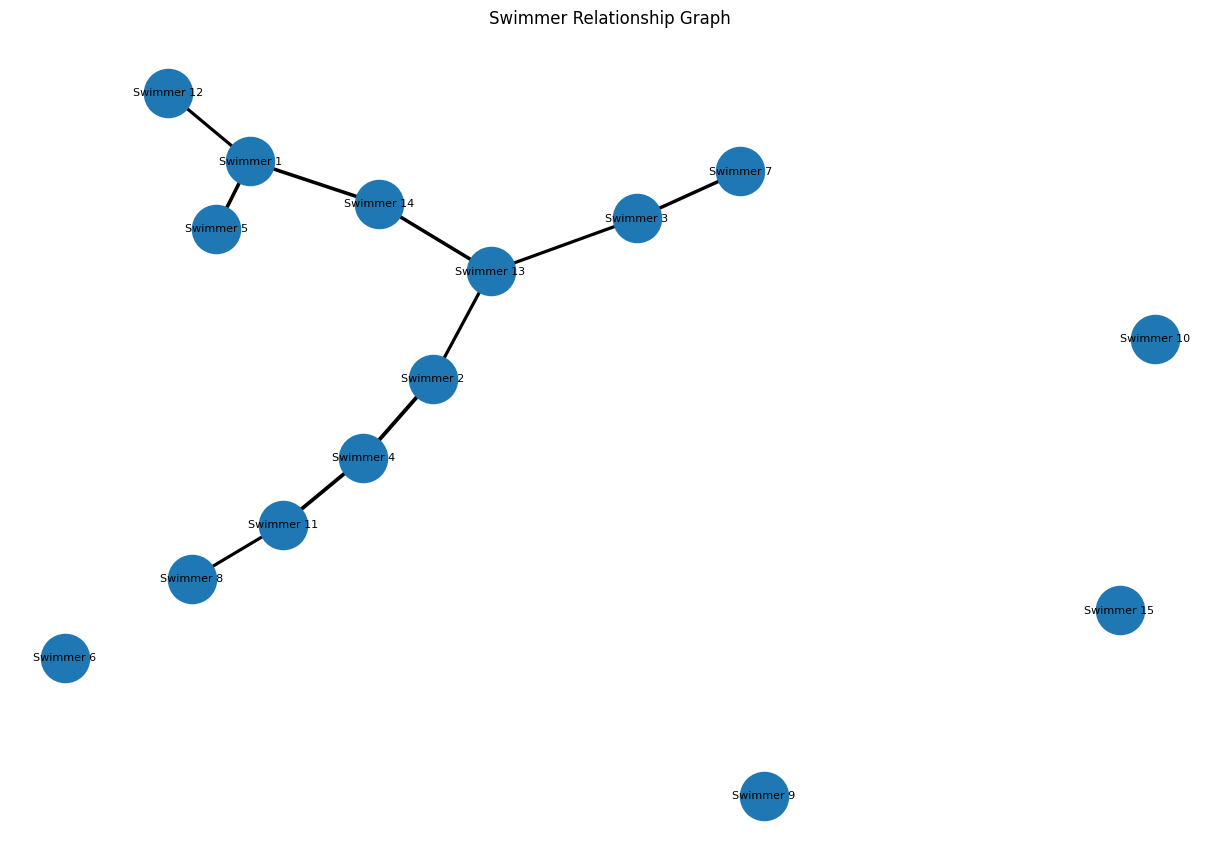

In [16]:
plt.figure(figsize=(12, 8))

positions = nx.spring_layout(
    G,
    seed=42,
    weight="weight"
)

nx.draw(
    G,
    positions,
    with_labels=True,
    node_size=1200,
    font_size=8,
    width=[
        1 + 4 * G[u][v]["weight"]
        for u, v in G.edges()
    ]
)

plt.title(
    "Swimmer Relationship Graph"
)
plt.show()

## 15. Inspect the graph relationships

The table below lists each edge and its correlation.

A larger weight means the two swimmers have more similar monthly patterns.

In [17]:
edge_table = pd.DataFrame([
    {
        "Swimmer_A": u,
        "Swimmer_B": v,
        "Correlation": round(
            data["weight"],
            3
        )
    }
    for u, v, data in G.edges(data=True)
])

edge_table.sort_values(
    "Correlation",
    ascending=False
).reset_index(drop=True)

,Swimmer_A,Swimmer_B,Correlation
0,Swimmer 2,Swimmer 4,0.449
1,Swimmer 11,Swimmer 4,0.428
2,Swimmer 1,Swimmer 14,0.392
3,Swimmer 1,Swimmer 5,0.389
4,Swimmer 13,Swimmer 14,0.382
5,Swimmer 3,Swimmer 7,0.366
6,Swimmer 13,Swimmer 3,0.326
7,Swimmer 13,Swimmer 2,0.322
8,Swimmer 1,Swimmer 12,0.316
9,Swimmer 11,Swimmer 8,0.316


## 16. Focus on the selected swimmer

This graph is similar to the type of graph used in the Assessment 3 logic:

- one focal node;
- several related nodes; and
- the edge value describes the strength of the relationship.

We connect the selected swimmer to the five swimmers with the most similar monthly patterns.

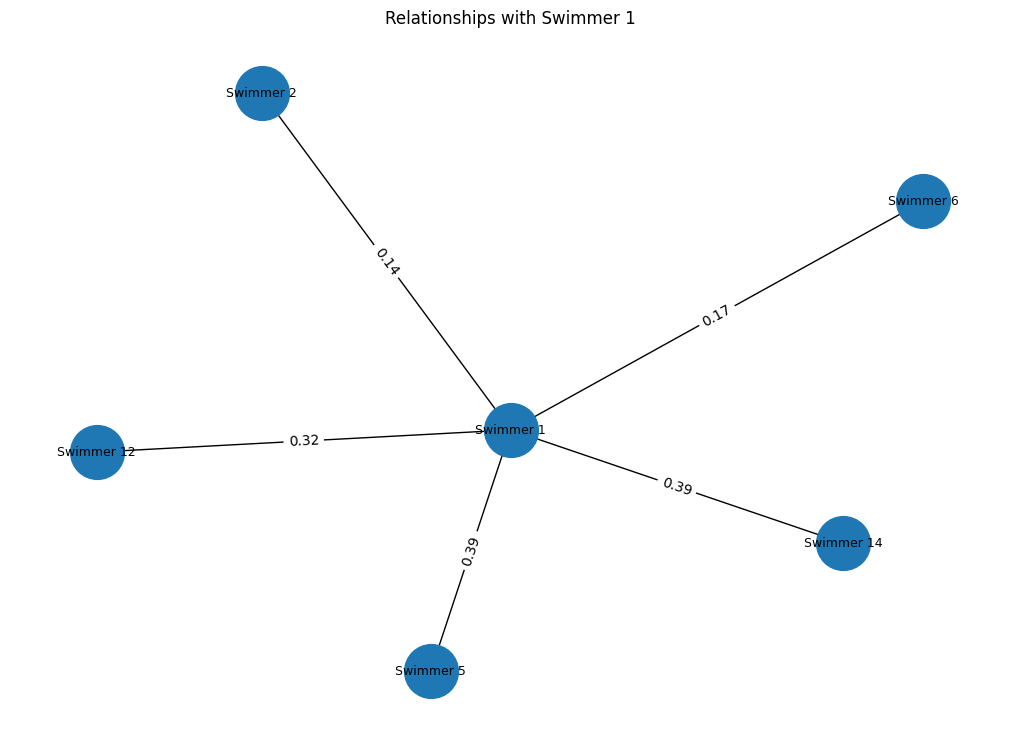

In [18]:
selected_correlations = (
    correlation_matrix[selected_swimmer]
    .drop(selected_swimmer)
    .sort_values(ascending=False)
    .head(5)
)

focal_graph = nx.Graph()

focal_graph.add_node(selected_swimmer)

for swimmer, correlation in selected_correlations.items():
    focal_graph.add_edge(
        selected_swimmer,
        swimmer,
        weight=float(correlation)
    )

focal_positions = nx.spring_layout(
    focal_graph,
    seed=42
)

plt.figure(figsize=(10, 7))

nx.draw(
    focal_graph,
    focal_positions,
    with_labels=True,
    node_size=1500,
    font_size=9
)

edge_labels = {
    (u, v): f"{data['weight']:.2f}"
    for u, v, data
    in focal_graph.edges(data=True)
}

nx.draw_networkx_edge_labels(
    focal_graph,
    focal_positions,
    edge_labels=edge_labels
)

plt.title(
    f"Relationships with {selected_swimmer}"
)
plt.show()

## 17. Centrality measures

Centrality helps describe the structural importance of nodes in a graph.

We calculate:

- **Degree centrality** — how many connections a swimmer has;
- **Betweenness centrality** — how often a swimmer lies between other swimmers;
- **Closeness centrality** — how close a swimmer is to other reachable nodes;
- **Eigenvector centrality** — importance based on connections to other important nodes; and
- **PageRank** — importance passed through graph connections.

In [19]:
degree_centrality = nx.degree_centrality(G)

betweenness_centrality = nx.betweenness_centrality(
    G,
    weight="weight"
)

closeness_centrality = nx.closeness_centrality(G)

eigenvector_centrality = nx.eigenvector_centrality(
    G,
    max_iter=1000,
    weight="weight"
)

pagerank = nx.pagerank(
    G,
    weight="weight"
)

centrality_table = pd.DataFrame({
    "Degree": degree_centrality,
    "Betweenness": betweenness_centrality,
    "Closeness": closeness_centrality,
    "Eigenvector": eigenvector_centrality,
    "PageRank": pagerank
})

centrality_table.sort_values(
    "PageRank",
    ascending=False
).round(3)

,Degree,Betweenness,Closeness,Eigenvector,PageRank
Swimmer 1,0.214,0.187,0.238,0.348,0.141
Swimmer 13,0.214,0.352,0.325,0.472,0.121
Swimmer 4,0.143,0.176,0.238,0.364,0.106
Swimmer 11,0.143,0.099,0.193,0.239,0.098
Swimmer 14,0.143,0.231,0.286,0.406,0.094
Swimmer 3,0.143,0.099,0.246,0.253,0.092
Swimmer 2,0.143,0.231,0.286,0.405,0.091
Swimmer 5,0.071,0.000,0.183,0.174,0.055
Swimmer 7,0.071,0.000,0.188,0.119,0.054
Swimmer 8,0.071,0.000,0.155,0.097,0.048


## 18. Visualise PageRank

Larger nodes represent larger PageRank values.

A swimmer can receive a higher PageRank when it is connected to other well-connected swimmers.

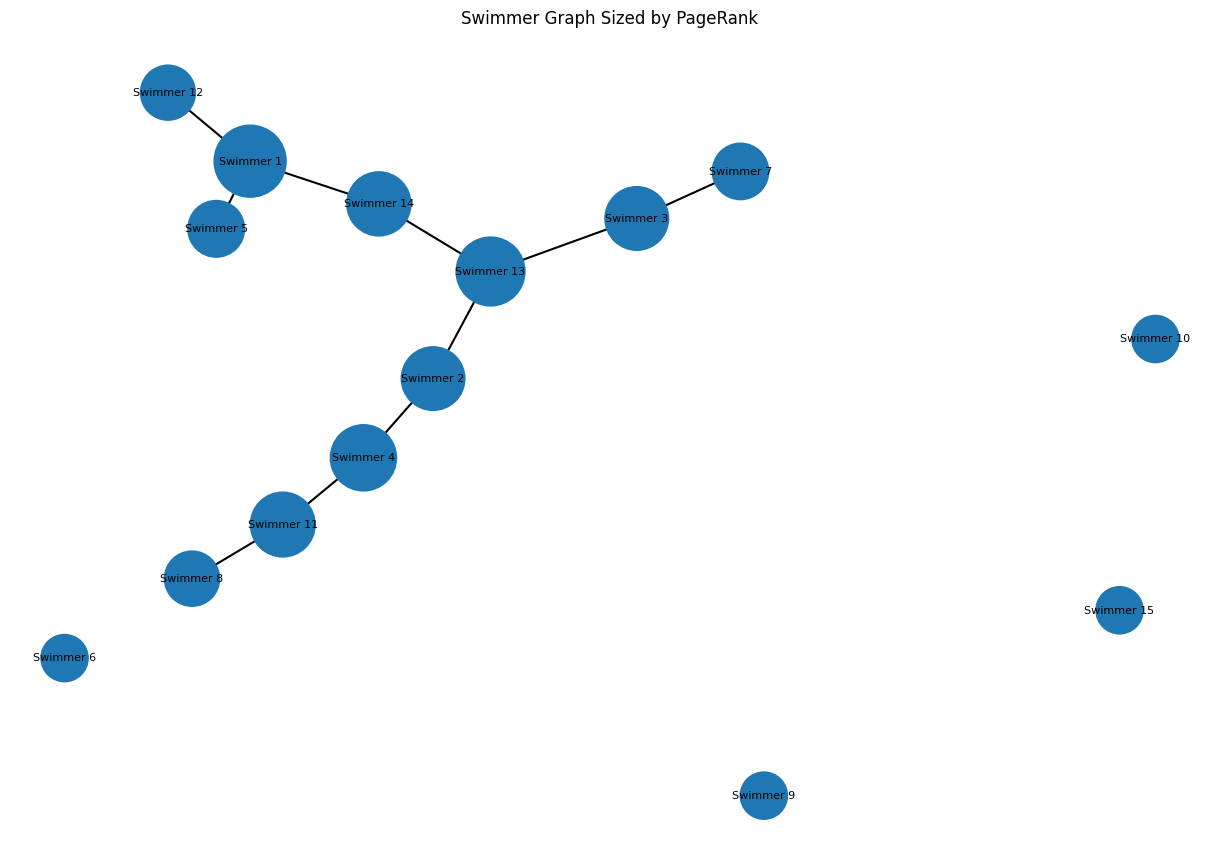

In [20]:
plt.figure(figsize=(12, 8))

pagerank_sizes = [
    1000 + pagerank[node] * 12000
    for node in G.nodes()
]

nx.draw(
    G,
    positions,
    with_labels=True,
    node_size=pagerank_sizes,
    font_size=8,
    width=1.5
)

plt.title(
    "Swimmer Graph Sized by PageRank"
)
plt.show()

# Part 3: Additional Graph Examples

The following examples come from the original Session 11 practical and show that graph relationships can be defined in many different ways.

## 19. Graph based on shared interests

Each person is a node.

Two people are connected if they share at least one interest.

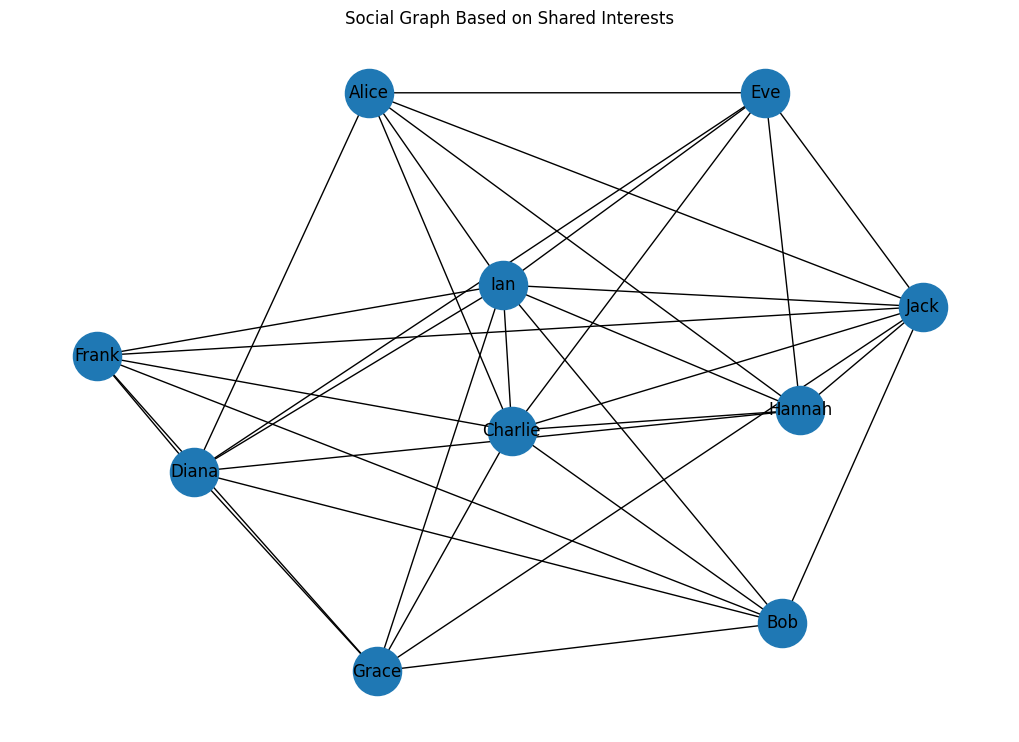

In [21]:
interest_data = {
    "Individual": [
        "Alice", "Bob", "Charlie", "Diana",
        "Eve", "Frank", "Grace", "Hannah",
        "Ian", "Jack"
    ],
    "Interest1": [
        "Music", "Sports", "Reading", "Music",
        "Art", "Sports", "Reading", "Art",
        "Music", "Reading"
    ],
    "Interest2": [
        "Art", "Reading", "Art", "Sports",
        "Music", "Reading", "Sports", "Music",
        "Reading", "Art"
    ]
}

interest_df = pd.DataFrame(
    interest_data
)

interest_graph = nx.Graph()

for person in interest_df["Individual"]:
    interest_graph.add_node(person)

for i in range(len(interest_df)):
    for j in range(i + 1, len(interest_df)):
        interests_i = set(
            interest_df.iloc[i][
                ["Interest1", "Interest2"]
            ]
        )

        interests_j = set(
            interest_df.iloc[j][
                ["Interest1", "Interest2"]
            ]
        )

        if interests_i.intersection(interests_j):
            interest_graph.add_edge(
                interest_df.iloc[i]["Individual"],
                interest_df.iloc[j]["Individual"]
            )

plt.figure(figsize=(10, 7))

nx.draw(
    interest_graph,
    nx.spring_layout(
        interest_graph,
        seed=42
    ),
    with_labels=True,
    node_size=1200
)

plt.title(
    "Social Graph Based on Shared Interests"
)
plt.show()

## 20. Customer similarity graph

Each customer is a node.

Two customers are connected when:

- their ages differ by no more than 5 years; and
- their spending scores differ by no more than 10 points.

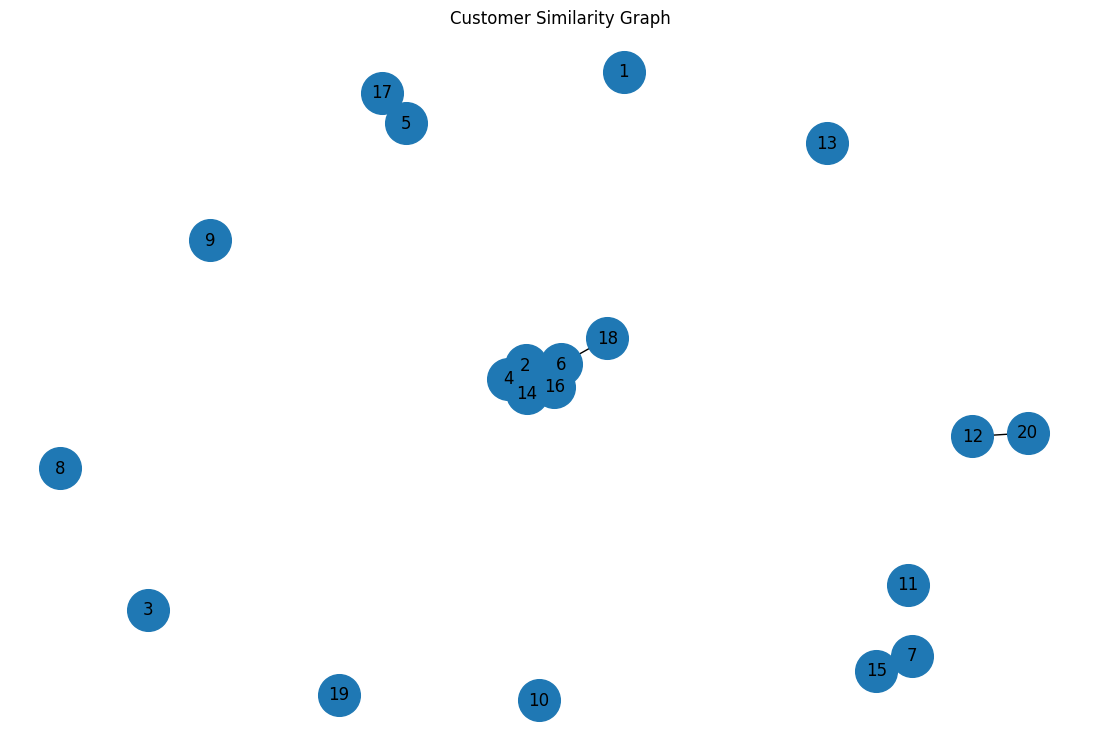

In [22]:
customer_data = {
    "CustomerID": range(1, 21),
    "Age": [
        25, 22, 20, 23, 31,
        22, 35, 23, 64, 30,
        67, 35, 58, 24, 37,
        22, 35, 20, 52, 35
    ],
    "Spending_Score": [
        39, 81, 6, 77, 40,
        76, 6, 94, 3, 72,
        14, 99, 15, 77, 13,
        79, 35, 66, 29, 98
    ]
}

customer_df = pd.DataFrame(
    customer_data
)

customer_graph = nx.Graph()

for _, row in customer_df.iterrows():
    customer_graph.add_node(
        int(row["CustomerID"]),
        Age=int(row["Age"]),
        Spending_Score=int(
            row["Spending_Score"]
        )
    )

for i in range(len(customer_df)):
    for j in range(i + 1, len(customer_df)):
        age_difference = abs(
            customer_df.iloc[i]["Age"]
            - customer_df.iloc[j]["Age"]
        )

        spending_difference = abs(
            customer_df.iloc[i]["Spending_Score"]
            - customer_df.iloc[j]["Spending_Score"]
        )

        if (
            age_difference <= 5
            and spending_difference <= 10
        ):
            customer_graph.add_edge(
                int(customer_df.iloc[i]["CustomerID"]),
                int(customer_df.iloc[j]["CustomerID"])
            )

plt.figure(figsize=(11, 7))

nx.draw(
    customer_graph,
    nx.spring_layout(
        customer_graph,
        seed=42
    ),
    with_labels=True,
    node_size=900
)

plt.title(
    "Customer Similarity Graph"
)
plt.show()

## Key takeaway

The most important decision in graph analytics is often:

> **What does an edge mean?**

Examples from this notebook:

- swimmer graph: similar monthly performance;
- focal swimmer graph: strength of correlation with one selected swimmer;
- interest graph: shared interests;
- customer graph: similar age and spending behaviour.

The graph should represent a meaningful relationship that helps answer the analytical question.